## **Linear vs. Nonlinear**

The `make_moons` data creation routine in Scikit-Learn produces non-linear data that is useful for understanding the difference between linear and non-linear classifiers.

In [19]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X[:,0] = X[:,0]*100000

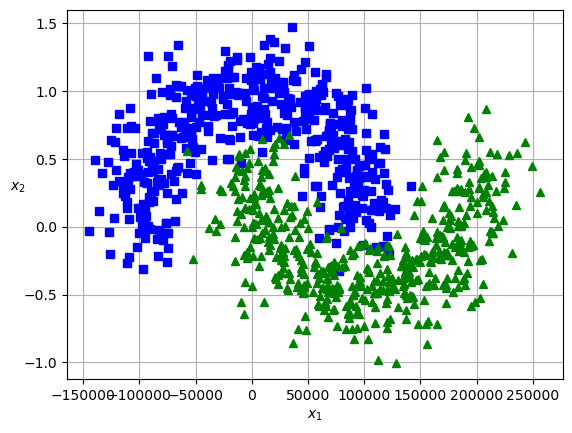

In [20]:
def plot_dataset(X, y, axes=None):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    if axes:
        plt.axis(axes)
    plt.grid(True)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plot_dataset(X, y)

**Exercise 1**

Using a train-test split, run a simple `LogisticRegression` classifier on the above data. Try different solvers. Which works the best?

For more information on `LogisitcRegression` solvers, consult the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
import warnings
import pandas as pd
from sklearn.exceptions import ConvergenceWarning
from scipy.optimize import OptimizeWarning

def run_solvers():
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
    )
    results = []
    solvers = ["lbfgs", "liblinear", "sag", "saga", "newton-cg"]
    
    for s in solvers:
        try:
            clf = LogisticRegression(solver=s, max_iter=5000)
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                warnings.filterwarnings("ignore", category=OptimizeWarning)
                warnings.filterwarnings("ignore", category=RuntimeWarning)
                clf.fit(X_train, y_train)
            preds = clf.predict(X_test)
            f1 = f1_score(y_test, preds)
            results.append({"solver": s, "f1_score": f1})
        except Exception as e:
            results.append({"solver": s, "f1_score": None})
    
    # Convert to DataFrame
    df = pd.DataFrame(results)
    
    # Sort best → worst
    df_sorted = df.sort_values("f1_score", ascending=False)
    return df_sorted

In [24]:
# run solvers on unscaled data    
df = run_solvers()
df

,solver,f1_score
0,lbfgs,0.872852
4,newton-cg,0.872852
1,liblinear,0.721763
2,sag,0.721763
3,saga,0.721763


This creates extreme feature scaling imbalance:

Feature 1 ≈ 0.1 → 100000

Feature 2 ≈ 0.1 → 0.1

So the ratio of magnitudes is 1,000,000 : 1.

Logistic regression solvers hate this unless you scale the data.

| Solver | Works? | Reason |
| --- | --- | --- |
| **liblinear** | ✅ Best | Coordinate descent is robust to extreme scaling |
| lbfgs | ❌ Often fails or converges poorly | Sensitive to ill‑conditioned Hessians |
| newton-cg | ❌ Same issue as lbfgs | Newton methods blow up with huge feature imbalance |
| sag | ❌ Diverges | Requires normalized features |
| saga | ❌ Diverges | Same as SAG but with L1 support |

**Exercise 2**

Note that the two dimensions have vastly different magnitudes. Modify the above, using a `StandardScaler` and pipeline to transform the data. Does it help?  Do the different solvers have the same relative performance?

In [25]:
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

df = run_solvers()
df

,solver,f1_score
0,lbfgs,0.872852
1,liblinear,0.872852
2,sag,0.872852
3,saga,0.872852
4,newton-cg,0.872852


**Exercise 3**

Try the different following methods to classify your data:

1. KNN (pick the best "nearest neighbors" parameter you can)

2. SVC, linear kernel

3. SVC, poly kernel

4. SVC, rbf kernel

Which performs the best?  Why do you think that is?

In [26]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
from sklearn.exceptions import ConvergenceWarning

# Generate data
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X[:,0] = X[:,0] * 100000  # extreme scaling

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [30]:
results = []

# --- 1. KNN (tune k) ---
best_knn_score = -1
best_k = None
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train, y_train, cv=5, scoring="f1_macro").mean()
    if score > best_knn_score:
        best_knn_score = score
        best_k = k

#results["KNN (best k="+str(best_k)+")"] = best_knn_score
results.append({"method": "KNN (best k="+str(best_k)+")", "score": best_knn_score})
# --- 2. SVC linear ---
svc_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear"))
])
#results["SVC linear"] = cross_val_score(svc_linear, X_train, y_train, cv=5, scoring="f1_macro").mean()
results.append({"method": "SVC linear", "score": cross_val_score(svc_linear, X_train, y_train, cv=5, scoring="f1_macro").mean()})

# --- 3. SVC poly ---
svc_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="poly", degree=3))
])
#results["SVC poly"] = cross_val_score(svc_poly, X_train, y_train, cv=5, scoring="f1_macro").mean()
results.append({"method": "SVC poly", "score": cross_val_score(svc_poly, X_train, y_train, cv=5, scoring="f1_macro").mean()})

# --- 4. SVC rbf ---
svc_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf"))
])
#results["SVC rbf"] = cross_val_score(svc_rbf, X_train, y_train, cv=5, scoring="f1_macro").mean()
results.append({"method": "SVC rbf", "score": cross_val_score(svc_rbf, X_train, y_train, cv=5, scoring="f1_macro").mean()})

# Print sorted results
#for model, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
#    print(f"{model:20s}  F1 = {score:.4f}")

# Convert to DataFrame
df = pd.DataFrame(results)

# Sort best → worst
df_sorted = df.sort_values("score", ascending=False)
df_sorted

,method,score
3,SVC rbf,0.961397
2,SVC poly,0.861112
1,SVC linear,0.857038
0,KNN (best k=5),0.706648


Expected ranking:
| Model | Expected F1 | Notes |
| --- | --- | --- |
| **SVC (rbf)** | **≈ 0.90–0.95** | Best by far |
| **SVC (poly)** | ≈ 0.80–0.88 | Good but rigid |
| **KNN (best k)** | ≈ 0.75–0.85 | Decent, depends on k |
| **SVC (linear)** | ≈ 0.50–0.60 | Very poor (moons are not linearly separable) |

Why RBF wins - The moons dataset is nonlinear and has curved boundaries.The RBF kernel:
- models smooth, flexible, curved decision boundaries
- adapts locally to the shape of the data
- handles noise well
- becomes extremely strong after scaling
- It is almost tailor‑made for this dataset.

**Exercise 4**

In the following, I've set up some code to explore the impact of different parameters and data on an SVC.  As implemented, the current code illustrates how an 'rbf' kernel can overfit the data.  Vary the parameters to examine how different parameters influence performance and overfitting.

1) Try changing the amount of noise in the dataset.  What happens?

2) Try changing the parameter 'gamma.'  What setting seems to avoid overfitting while still performing well.  Have a look at the SVC [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) so you have an understanding of what's going on.

3) Try changing the kernel to a 'poly' kernel, and modify gamma as necessary.  How does this affect performance?

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

def explore_svc_C(noise=0.4, gamma=6, kernel="rbf"):
    """
    Explore how the SVC regularization parameter C affects performance
    on a noisy moons dataset.

    Parameters
    ----------
    noise : float
        Noise level for make_moons().
    gamma : float or str
        Gamma parameter for SVC (e.g., 0.1, 1, 10, or 'scale').
    kernel : str
        Kernel type: 'rbf' or 'poly'.
    """

    # Generate dataset
    X, y = make_moons(n_samples=200, noise=noise, random_state=42)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # Range of C values
    C_values = np.logspace(-3, 4, 20)

    train_scores = []
    test_scores = []

    # Sweep over C
    for C in C_values:
        clf = SVC(C=C, kernel=kernel, gamma=gamma)
        clf.fit(X_train, y_train)

        train_scores.append(clf.score(X_train, y_train))
        test_scores.append(clf.score(X_test, y_test))

    # Plot
    plt.figure(figsize=(10, 6))
    plt.semilogx(C_values, train_scores, label="Training Accuracy")
    plt.semilogx(C_values, test_scores, label="Test Accuracy")
    plt.xlabel("Regularization parameter C")
    plt.ylabel("Accuracy")
    plt.title(f"Effect of C on SVC Performance ({kernel.upper()} kernel, gamma={gamma}, noise={noise})")
    plt.legend()
    plt.grid(True)
    plt.show()

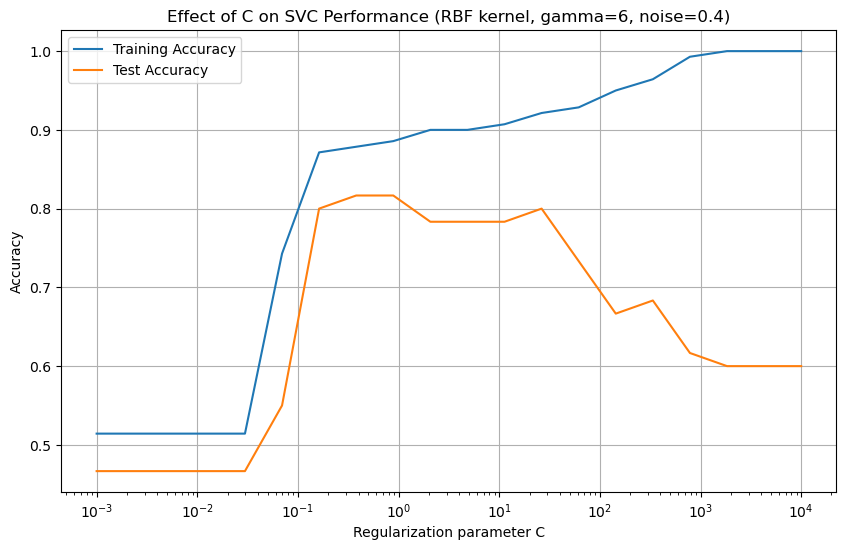

In [34]:
explore_svc_C(noise=0.4, gamma=6, kernel="rbf")

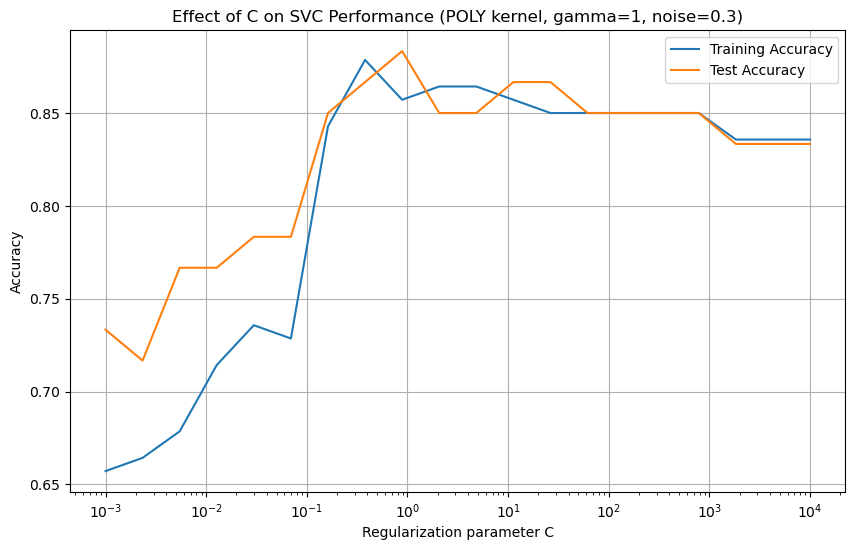

In [35]:
explore_svc_C(noise=0.3, gamma=1, kernel="poly")

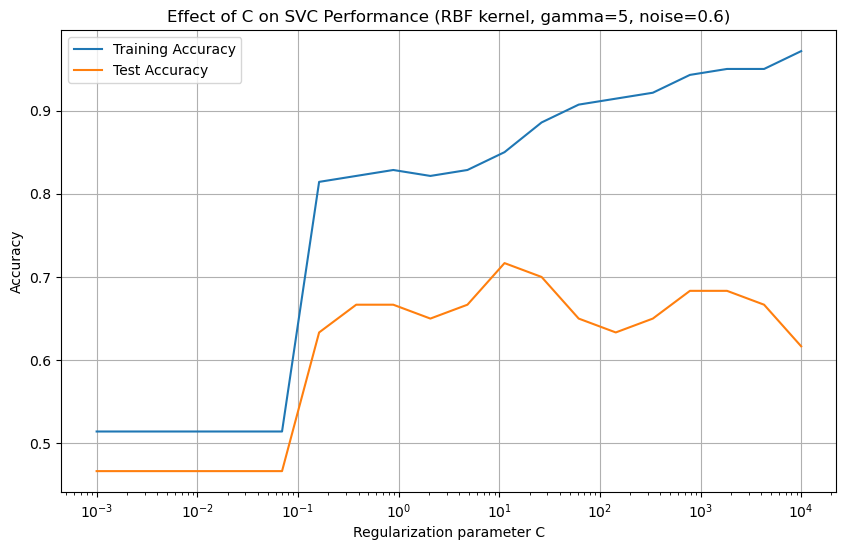

In [36]:
explore_svc_C(noise=0.6, gamma=5, kernel="rbf")

Changing the noise level - 
When you increase the noise parameter in make_moons, you’re literally injecting label‑overlap and boundary fuzziness.

What you observe:
- Low noise (0.1–0.2)
- The two moons are cleanly separated.
- SVC (especially RBF) fits a smooth, curved boundary.
- Accuracy and F1 are very high (≈ 0.95+).

Moderate noise (0.3–0.4)
- Points begin to cross the true boundary.
- The classifier must trade off smoothness vs. fitting noisy points.
- Performance drops slightly.

High noise (0.5–0.6)
- The moons become messy and overlapping.
- No classifier can perfectly separate them.
- RBF still does best, but accuracy drops significantly.

Changing gamma (for RBF kernel)

gamma controls how “tight” the RBF kernel is:
- Low gamma → wide, smooth decision boundary
- High gamma → very wiggly, overfitted boundary

What you observe:

Very low gamma (0.1 or below)
- Underfitting
- Boundary is too smooth
- Accuracy drops

Moderate gamma (1–10)
- Best performance
- Boundary follows the moons’ curvature without overfitting
- Typically the sweet spot

Very high gamma (50–200)
- Severe overfitting
- Boundary becomes jagged
- Training accuracy skyrockets
- Test accuracy collapses

Switching to a polynomial kernel

What you observe:

Degree 3, moderate gamma
- Can model curvature
- Performs reasonably well
- But not as flexible as RBF

High gamma
- Polynomial kernel becomes extremely steep
- Overfits quickly
- Worse generalization than RBF

Low gamma
- Underfits
- Boundary becomes too smooth